# DESC ELAsTiCC2 — SALT3 fit with free redshift

- **author** : Sylvie Dagoret-Campagne
- **affiliation** : IJCLab/IN2P3/CNRS — Université Paris-Saclay
- **creation date** : 2026-05-08
- **based on** : `02_sncosmo/03_elasticc2_fitsalt3_lightcurves.ipynb`

## Purpose

In the real observational scenario, the redshift of a transient is **not known a priori**
(except when a spectroscopic host redshift is available, which is not guaranteed).
This notebook therefore fits the **five SALT3 parameters simultaneously**:

$$
\text{free params} = \{z,\; t_0,\; x_0,\; x_1,\; c\}
$$

The truth redshift `ZCMB` from the ELAsTiCC2 catalogue is **only used**:
1. to define the search bound `[z_lo, z_hi]` (realistic bounds, not cheat values),
2. as the reference for validation at the end of the notebook.

## Redshift fitting strategy

Fitting redshift from broadband light curves alone is notoriously degenerate:
the colour `c` and the redshift `z` both shift spectral features,
and the amplitude `x0` absorbs the luminosity-distance dependence.
A single local minimisation starting from a poor initial guess
frequently lands in a wrong local minimum.

We use a **two-pass strategy**:

1. **Coarse grid scan** — for a grid of `N_GRID_Z` redshift values spanning
   `[Z_BOUND_LO, Z_BOUND_HI]`, fix `z` and run a fast 4-parameter fit
   `(t0, x0, x1, c)`.  Record the χ².
2. **Refined free-z fit** — initialise at the `z` value that gave the lowest χ²
   in the grid scan, then run `sncosmo.fit_lc` with all 5 parameters free
   within a narrow window around that starting point.

This makes the fit robust against the multi-modality of the χ²(z) surface.

## Final diagnostic figure

The last section produces an **errorbar plot** of `z_fit ± σ_z` versus `z_true`
with a reference diagonal, colour-coded by χ²/dof, plus a residual panel
showing $\Delta z / (1 + z_{\rm true})$ (redshift bias in velocity units).

### References
- Kenworthy et al. 2021 — SALT3: https://doi.org/10.3847/1538-4357/ac30d8
- sncosmo documentation: https://sncosmo.readthedocs.io/en/stable/index.html
- ELAsTiCC2 dataset: DESC TD public data
- Notebook `02_sncosmo/03_elasticc2_fitsalt3_lightcurves.ipynb` — z-fixed baseline


## 0 · Imports

In [1]:
%matplotlib inline

import sys
import os
import math
import pathlib
import logging
import warnings

import numpy as np
import pandas as pd
import astropy.table
import matplotlib
from matplotlib import pyplot as plt

import sncosmo

# ── local library ──────────────────────────────────────────────────────────────
libdir = pathlib.Path(os.getcwd()).parent.parent / "lib_elasticc2"
sys.path.insert(0, str(libdir))
from transcientslightcurves import elasticc2_snana_reader

# ── logging ────────────────────────────────────────────────────────────────────
_logger = logging.getLogger("main")
if not _logger.hasHandlers():
    _logout = logging.StreamHandler(sys.stderr)
    _logger.addHandler(_logout)
    _logout.setFormatter(logging.Formatter(
        '[%(asctime)s - %(levelname)s] - %(message)s',
        datefmt='%Y-%m-%d %H:%M:%S'
    ))
_logger.setLevel(logging.INFO)
_logger.info("Imports done.")

[2026-05-08 09:53:13 - INFO] - Imports done.


In [2]:
try:
    import ipympl  # noqa: F401
    %matplotlib widget
    print("ipympl found → interactive backend (%matplotlib widget)")
except ImportError:
    %matplotlib inline
    print("ipympl NOT found → %matplotlib inline")

ipympl found → interactive backend (%matplotlib widget)


## 1 · Parameters

In [3]:
# ── Data selection ─────────────────────────────────────────────────────────────
OBJ_CLASS      = 'SNIa-SALT3'
Z_MIN          = 0.1            # truth-redshift lower bound for sample selection
Z_MAX          = 1.0            # truth-redshift upper bound
FILE_NUM       = 1
MIN_DETECTIONS = 8
DETECTED_ONLY  = True
N_CURVES       = 200            # events to fit
RANDOM_SEED    = 42

# ── SALT3 model ────────────────────────────────────────────────────────────────
SALT3_SOURCE  = 'salt3'
SALT3_VERSION = '2.0'
ZP            = 31.4
ZPSYS         = 'ab'
BANDS         = ['u', 'g', 'r', 'i', 'z', 'y']
BAND_PREFIX   = 'lsst'

# ── Redshift fit bounds ────────────────────────────────────────────────────────
# These bounds are applied to the z fit without using truth z.
# They represent the realistic prior knowledge: LSST SNIa are expected at z < 1.2.
# The SALT3 template covers rest-frame wavelengths 2000–11000 Å;
# the bluest LSST band (u, λ_eff ≈ 3700 Å) sets a practical lower limit ~0.02.
Z_BOUND_LO = 0.02      # hard lower bound for z in the fit
Z_BOUND_HI = 1.20      # hard upper bound for z in the fit

# ── Two-pass strategy parameters ──────────────────────────────────────────────
# Pass 1: coarse grid scan over z to find the best starting point
N_GRID_Z   = 30         # number of z grid points in the coarse scan

# Pass 2: refined free-z fit, with z bounded within ±Z_REFINE_HALF around best grid z
Z_REFINE_HALF = 0.15    # half-width of the z search window for the refined fit

# ── Data path ──────────────────────────────────────────────────────────────────
DATA_DIR   = "/Users/dagoret/DATA/DESC_TD_PUBLIC/ELASTICC/ELASTICC2_TRAINING_SAMPLE_2"
DIR_PREFIX = "ELASTICC2_TRAIN_02_"

# ── Colours per band ───────────────────────────────────────────────────────────
BAND_COLORS = {
    'u': '#cc0ccc', 'g': '#00cc44', 'r': '#cc0000',
    'i': '#ff4400', 'z': '#886600', 'y': '#442200'
}
NCOLS = 4

rng = np.random.default_rng(seed=RANDOM_SEED)
print(f"SALT3 source : {SALT3_SOURCE}  v{SALT3_VERSION}")
print(f"Redshift fit : z ∈ [{Z_BOUND_LO}, {Z_BOUND_HI}]  (no truth used)")
print(f"Grid scan    : {N_GRID_Z} points  |  refine window: ±{Z_REFINE_HALF}")
print(f"N_CURVES     : {N_CURVES}")

SALT3 source : salt3  v2.0
Redshift fit : z ∈ [0.02, 1.2]  (no truth used)
Grid scan    : 30 points  |  refine window: ±0.15
N_CURVES     : 200


## 2 · SALT3 model check

In [4]:
salt3_model = sncosmo.Model(
    source=sncosmo.get_source(SALT3_SOURCE, version=SALT3_VERSION)
)
print(f"Model       : {salt3_model.source.name}  v{salt3_model.source.version}")
print(f"Parameters  : {salt3_model.param_names}")
print(f"Phase range : {salt3_model.source.minphase():.1f} – "
      f"{salt3_model.source.maxphase():.1f} days")
print(f"Wave range  : {salt3_model.source.minwave():.0f} – "
      f"{salt3_model.source.maxwave():.0f} Å")

# Maximum redshift compatible with the u-band observer frame
# lsst-u effective wavelength ≈ 3700 Å; SALT3 starts at 2000 Å rest-frame
# → z_max ≈ (3700/2000) - 1 ≈ 0.85 before u falls below model range
# In practice sncosmo extrapolates gracefully; we cap at Z_BOUND_HI.
print(f"\nFit bounds: z ∈ [{Z_BOUND_LO}, {Z_BOUND_HI}]")

print("\nLSST band registration:")
for b in BANDS:
    bp = sncosmo.get_bandpass(BAND_PREFIX + b)
    print(f"  lsst{b}  λ_eff={bp.wave_eff:.0f} Å  ✓")

Model       : salt3  v2.0
Parameters  : ['z', 't0', 'x0', 'x1', 'c']
Phase range : -20.0 – 50.0 days
Wave range  : 2000 – 11000 Å

Fit bounds: z ∈ [0.02, 1.2]

LSST band registration:
  lsstu  λ_eff=3671 Å  ✓
  lsstg  λ_eff=4827 Å  ✓
  lsstr  λ_eff=6223 Å  ✓
  lssti  λ_eff=7546 Å  ✓
  lsstz  λ_eff=8691 Å  ✓
  lssty  λ_eff=9710 Å  ✓


## 3 · Load ELAsTiCC2 data

In [5]:
esr = elasticc2_snana_reader(DATA_DIR, dir_prefix=DIR_PREFIX)

_logger.info(f"Loading {OBJ_CLASS}...")
head      = esr.get_head(OBJ_CLASS, return_format='pandas')
truth     = esr.get_object_truth(OBJ_CLASS, return_format='pandas')
all_ltcvs = esr.get_all_ltcvs(OBJ_CLASS, file_num=FILE_NUM, return_format='pandas')
_logger.info("Done.")

print(f"{all_ltcvs['SNID'].nunique()} objects loaded.")
print(f"Columns: {list(all_ltcvs.columns)}")

[2026-05-08 09:53:14 - INFO] - Loading SNIa-SALT3...
[2026-05-08 09:53:14 - INFO] - Reading HEAD files from /Users/dagoret/DATA/DESC_TD_PUBLIC/ELASTICC/ELASTICC2_TRAINING_SAMPLE_2/ELASTICC2_TRAIN_02_SNIa-SALT3
[2026-05-08 09:53:16 - INFO] - Reading /Users/dagoret/DATA/DESC_TD_PUBLIC/ELASTICC/ELASTICC2_TRAINING_SAMPLE_2/ELASTICC2_TRAIN_02_SNIa-SALT3/ELASTICC2_TRAIN_02_SNIa-SALT3.DUMP
[2026-05-08 09:53:17 - INFO] - Reading /Users/dagoret/DATA/DESC_TD_PUBLIC/ELASTICC/ELASTICC2_TRAINING_SAMPLE_2/ELASTICC2_TRAIN_02_SNIa-SALT3/ELASTICC2_TRAIN_02_NONIaMODEL0-0001_PHOT.FITS.gz...
[2026-05-08 09:53:18 - INFO] - ...assigning SNID
[2026-05-08 09:53:18 - DEBUG] - Concatenating 1 dataframes
[2026-05-08 09:53:18 - DEBUG] - Sorting
[2026-05-08 09:53:18 - DEBUG] - Returning
[2026-05-08 09:53:18 - INFO] - Done.


4247 objects loaded.
Columns: ['MJD', 'BAND', 'PHOTFLAG', 'PHOTPROB', 'FLUXCAL', 'FLUXCALERR', 'PSF_SIG1', 'SKY_SIG', 'RDNOISE', 'ZEROPT', 'ZEROPT_ERR', 'GAIN', 'SIM_MAGOBS', 'SNID']


In [6]:
detcounts = (
    all_ltcvs[(all_ltcvs['PHOTFLAG'] & esr.photflag_detect) != 0]
    .groupby('SNID').agg('count')['MJD']
    .reset_index().rename({'MJD': 'ndetect'}, axis=1)
)
truth_counts = truth.join(detcounts.set_index('SNID'), on='SNID', how='inner')
subset = truth_counts[
    (truth_counts['ZCMB'] >= Z_MIN) &
    (truth_counts['ZCMB'] <  Z_MAX) &
    (truth_counts['ndetect'] >= MIN_DETECTIONS)
].copy()
print(f"{len(subset)} objects pass selection.")

1199 objects pass selection.


## 4 · Helper functions

### 4.1 · ELAsTiCC2 → sncosmo table

In [7]:
def make_sncosmo_table(ltcv_df, detected_only=True,
                       photflag_detect=None,
                       zp=ZP, zpsys=ZPSYS,
                       band_prefix=BAND_PREFIX):
    """Convert an ELAsTiCC2 light-curve DataFrame to an astropy.Table
    suitable for sncosmo.fit_lc."""
    df = ltcv_df.copy()
    if detected_only and photflag_detect is not None:
        df = df[(df['PHOTFLAG'] & photflag_detect) != 0]
    df = df[df['FLUXCALERR'] > 0].copy()
    df['BAND'] = df['BAND'].str.strip().str.lower()
    df['band_sncosmo'] = band_prefix + df['BAND']
    return astropy.table.Table({
        'time'    : df['MJD'].values.astype(float),
        'band'    : df['band_sncosmo'].values,
        'flux'    : df['FLUXCAL'].values.astype(float),
        'fluxerr' : df['FLUXCALERR'].values.astype(float),
        'zp'      : np.full(len(df), zp, dtype=float),
        'zpsys'   : np.full(len(df), zpsys),
    })

print("make_sncosmo_table ready.")

make_sncosmo_table ready.


### 4.2 · Two-pass SALT3 fitter with free redshift

**Pass 1 — coarse grid scan**  
For each `z` in a uniform grid over `[Z_BOUND_LO, Z_BOUND_HI]`, the model is
initialised at that `z` (fixed) and a fast 4-parameter fit `(t0, x0, x1, c)` is run.
The grid point with the lowest χ² becomes the starting point for pass 2.

**Pass 2 — refined free-z fit**  
All 5 parameters `(z, t0, x0, x1, c)` are freed, with `z` bounded within
`[z_best − Z_REFINE_HALF, z_best + Z_REFINE_HALF]` (clipped to global bounds).
The covariance matrix from this fit provides `σ_z` and the other uncertainties.

In [8]:
def fit_salt3_free_z(ltcv_df, photflag_detect=None,
                     z_init_hint=None) -> dict:
    """Fit a single ELAsTiCC2 event with SALT3, treating z as a free parameter.

    Uses a two-pass strategy:
      Pass 1 — coarse grid scan over z → best starting z_grid
      Pass 2 — refined 5-parameter free fit around z_grid

    Parameters
    ----------
    ltcv_df         : DataFrame for one SNID
    photflag_detect : bitmask for detections
    z_init_hint     : optional initial z hint (e.g. host photo-z);
                      if provided, the grid is centred on this value instead
                      of spanning the full [Z_BOUND_LO, Z_BOUND_HI] range

    Returns
    -------
    dict with keys: success, z, z_err, t0, x0, x1, c, chi2, ndof, chi2_red,
                    vcov, param_errors, z_grid, chi2_grid, z_grid_best,
                    fitted_model, table, message
    """
    # ── Build observation table ────────────────────────────────────────────────
    try:
        obs = make_sncosmo_table(ltcv_df, detected_only=DETECTED_ONLY,
                                 photflag_detect=photflag_detect)
    except Exception as e:
        return {'success': False, 'message': f'Table error: {e}'}
    if len(obs) < 6:
        return {'success': False, 'message': 'Too few data points'}

    t0_guess = float(obs['time'][np.argmax(obs['flux'])])

    # ── Define coarse z grid ──────────────────────────────────────────────────
    if z_init_hint is not None:
        z_lo = max(Z_BOUND_LO, z_init_hint - Z_REFINE_HALF)
        z_hi = min(Z_BOUND_HI, z_init_hint + Z_REFINE_HALF)
    else:
        z_lo = Z_BOUND_LO
        z_hi = Z_BOUND_HI
    z_grid = np.linspace(z_lo, z_hi, N_GRID_Z)

    # ── Pass 1: coarse scan ───────────────────────────────────────────────────
    chi2_grid   = np.full(N_GRID_Z, np.inf)
    bounds_4par = {
        't0' : (t0_guess - 30.0, t0_guess + 30.0),
        'x0' : (1e-8, 1.0),
        'x1' : (-5.0, 5.0),
        'c'  : (-0.5, 0.5),
    }

    for k, z_try in enumerate(z_grid):
        m = sncosmo.Model(
            source=sncosmo.get_source(SALT3_SOURCE, version=SALT3_VERSION)
        )
        m.set(z=z_try, t0=t0_guess, x0=1e-4, x1=0.0, c=0.0)
        try:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                res_k, _ = sncosmo.fit_lc(
                    obs, m,
                    vparam_names=['t0', 'x0', 'x1', 'c'],
                    bounds=bounds_4par,
                    minsnr=0.0, warn=False
                )
            chi2_grid[k] = res_k.chisq
        except Exception:
            pass

    best_k    = int(np.argmin(chi2_grid))
    z_grid_best = float(z_grid[best_k])

    # ── Pass 2: refined free-z fit ────────────────────────────────────────────
    z_ref_lo = max(Z_BOUND_LO, z_grid_best - Z_REFINE_HALF)
    z_ref_hi = min(Z_BOUND_HI, z_grid_best + Z_REFINE_HALF)

    model_final = sncosmo.Model(
        source=sncosmo.get_source(SALT3_SOURCE, version=SALT3_VERSION)
    )
    model_final.set(z=z_grid_best, t0=t0_guess, x0=1e-4, x1=0.0, c=0.0)

    bounds_5par = {
        'z'  : (z_ref_lo, z_ref_hi),
        't0' : (t0_guess - 30.0, t0_guess + 30.0),
        'x0' : (1e-8, 1.0),
        'x1' : (-5.0, 5.0),
        'c'  : (-0.5, 0.5),
    }

    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            result, fitted_model = sncosmo.fit_lc(
                obs, model_final,
                vparam_names=['z', 't0', 'x0', 'x1', 'c'],
                bounds=bounds_5par,
                minsnr=0.0, warn=False
            )
    except Exception as e:
        return {
            'success': False,
            'message': f'Pass-2 fit failed: {e}',
            'z_grid': z_grid,
            'chi2_grid': chi2_grid,
            'z_grid_best': z_grid_best,
            'table': obs,
        }

    chi2     = float(result.chisq)
    ndof     = int(result.ndof)
    chi2_red = chi2 / max(ndof, 1)

    # ── Covariance and 1-sigma errors ─────────────────────────────────────────
    vparam_names = ['z', 't0', 'x0', 'x1', 'c']
    vcov = result.covariance
    param_errors = {}
    if vcov is not None:
        diag = np.diag(vcov)
        for i, p in enumerate(vparam_names):
            param_errors[p] = float(np.sqrt(max(diag[i], 0.0)))

    return {
        'success'      : True,
        'result'       : result,
        'fitted_model' : fitted_model,
        'table'        : obs,
        'vparam_names' : vparam_names,
        'z'            : float(fitted_model['z']),
        'z_err'        : param_errors.get('z', float('nan')),
        't0'           : float(fitted_model['t0']),
        'x0'           : float(fitted_model['x0']),
        'x1'           : float(fitted_model['x1']),
        'c'            : float(fitted_model['c']),
        'chi2'         : chi2,
        'ndof'         : ndof,
        'chi2_red'     : chi2_red,
        'vcov'         : vcov,
        'param_errors' : param_errors,
        'z_grid'       : z_grid,
        'chi2_grid'    : chi2_grid,
        'z_grid_best'  : z_grid_best,
        'message'      : result.message,
    }

print("Two-pass free-z fitter ready.")

Two-pass free-z fitter ready.


## 5 · Select events and run fits

In [9]:
n_avail      = min(N_CURVES, len(subset))
chosen_idx   = rng.choice(len(subset), size=n_avail, replace=False)
chosen_snids = subset['SNID'].values[chosen_idx]
print(f"Selected {n_avail} SNIDs for free-z SALT3 fitting.")

Selected 200 SNIDs for free-z SALT3 fitting.


In [10]:
fit_results = {}

for snid in chosen_snids:
    ltcv   = all_ltcvs[all_ltcvs['SNID'] == snid]
    z_row  = truth[truth['SNID'] == snid]['ZCMB'].values
    z_true = float(z_row[0]) if len(z_row) else np.nan

    # Truth z is NOT passed to the fitter — only used here for display
    res = fit_salt3_free_z(ltcv, photflag_detect=esr.photflag_detect)
    fit_results[snid] = res

    if res['success']:
        pe = res['param_errors']
        dz = res['z'] - z_true
        print(
            f"  SNID {snid:8d}  ✓  "
            f"z_true={z_true:.4f}  z_fit={res['z']:.4f}±{pe.get('z',float('nan')):.4f}  "
            f"Δz={dz:+.4f}  "
            f"x1={res['x1']:+.3f}  c={res['c']:+.3f}  "
            f"χ²/dof={res['chi2_red']:.2f}"
        )
    else:
        print(f"  SNID {snid:8d}  ✗  {res['message']}")

  SNID 42107438  ✓  z_true=0.5128  z_fit=1.0445±0.0230  Δz=+0.5317  x1=+0.204  c=-0.429  χ²/dof=1.27
  SNID 29989905  ✓  z_true=0.3983  z_fit=0.8872±0.0005  Δz=+0.4889  x1=+1.112  c=-0.383  χ²/dof=1.61
  SNID 24244586  ✓  z_true=0.5183  z_fit=0.6956±0.0483  Δz=+0.1773  x1=+1.745  c=-0.200  χ²/dof=0.62
  SNID  6201746  ✓  z_true=0.1075  z_fit=1.1212±0.1354  Δz=+1.0137  x1=-1.809  c=-0.401  χ²/dof=0.40
  SNID 52142184  ✓  z_true=0.4895  z_fit=1.1557±0.0575  Δz=+0.6662  x1=-1.011  c=-0.347  χ²/dof=2.26
  SNID 57008519  ✓  z_true=0.1212  z_fit=0.1105±0.0015  Δz=-0.0107  x1=-1.276  c=-0.111  χ²/dof=37.31
  SNID   111264  ✓  z_true=0.1503  z_fit=0.1715±0.0035  Δz=+0.0212  x1=-1.304  c=-0.115  χ²/dof=8.70
  SNID  5289297  ✓  z_true=0.2600  z_fit=0.2501±0.0106  Δz=-0.0098  x1=+0.434  c=+0.174  χ²/dof=0.78
  SNID  3637227  ✓  z_true=0.4653  z_fit=1.1295±0.0422  Δz=+0.6642  x1=-1.502  c=-0.413  χ²/dof=0.78
  SNID 31325078  ✓  z_true=0.8153  z_fit=0.9405±0.0842  Δz=+0.1252  x1=+0.364  c=-0.146  χ

## 6 · Per-event plot: light curve + χ²(z) grid scan

For each event two panels are shown side by side:
- **Left**: multi-band light curve with fitted SALT3 model.
- **Right**: χ²(z) from the coarse grid scan; the best-z from the grid (Pass 1) and
  the final fitted z (Pass 2) are marked, with the truth z shown for reference.

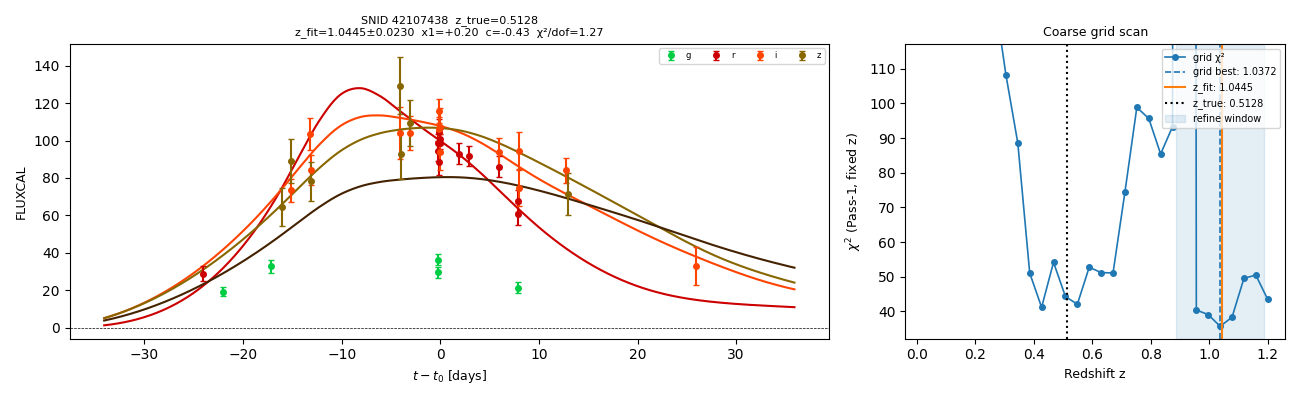

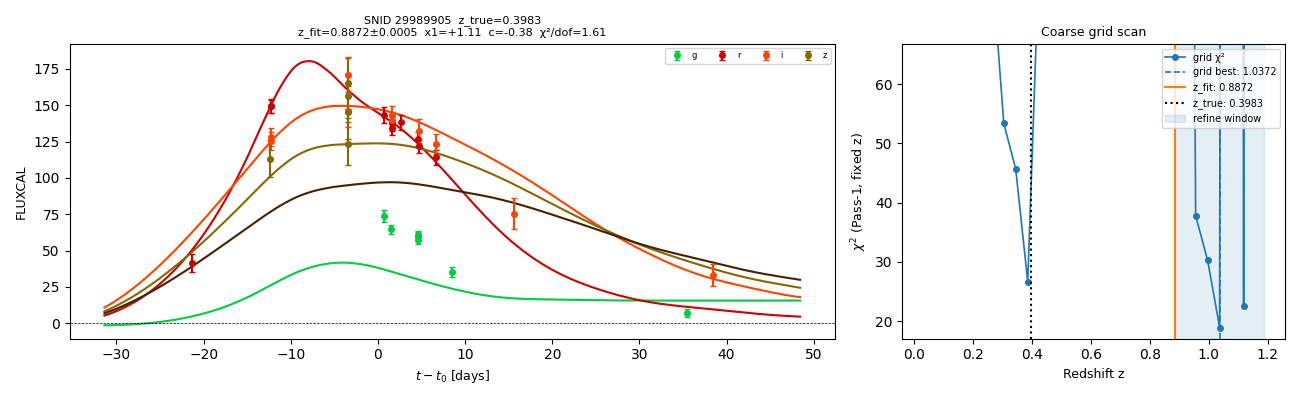

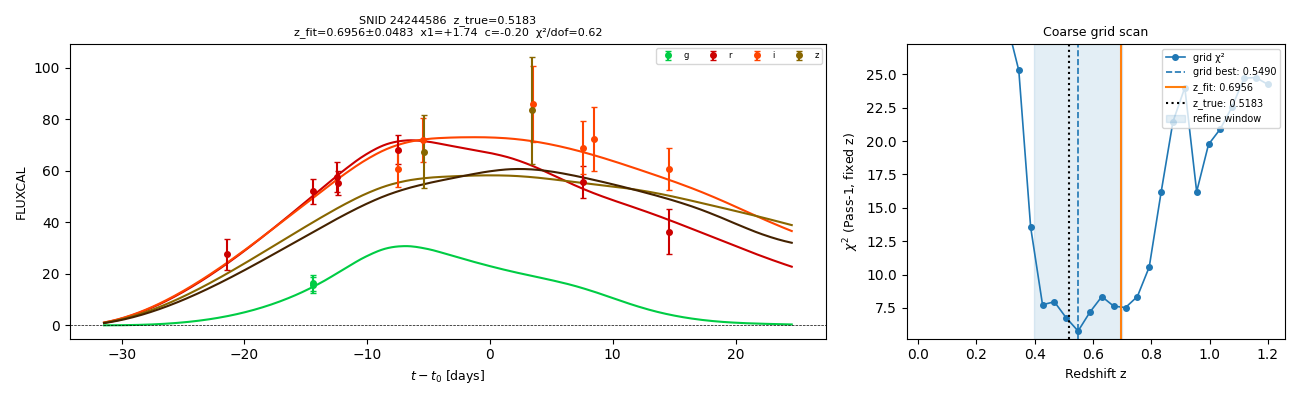

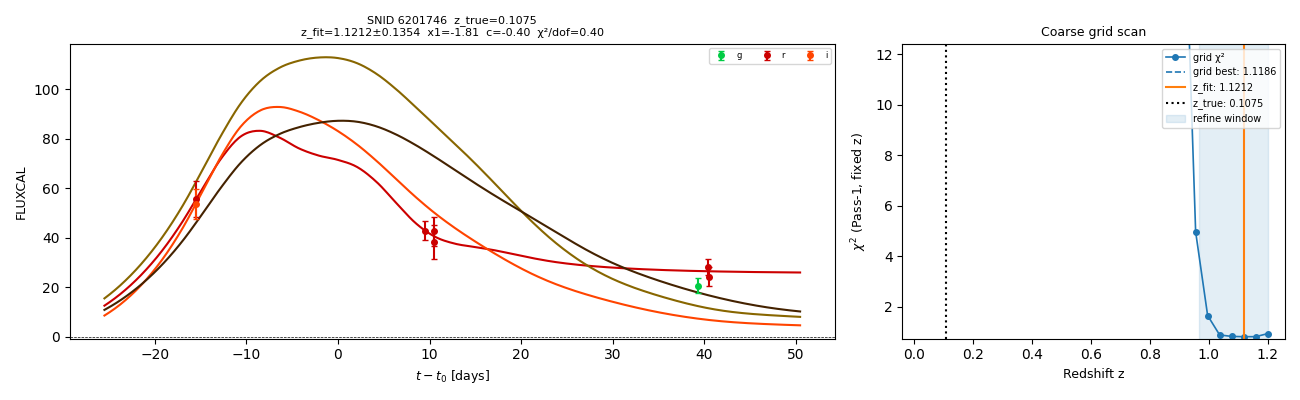

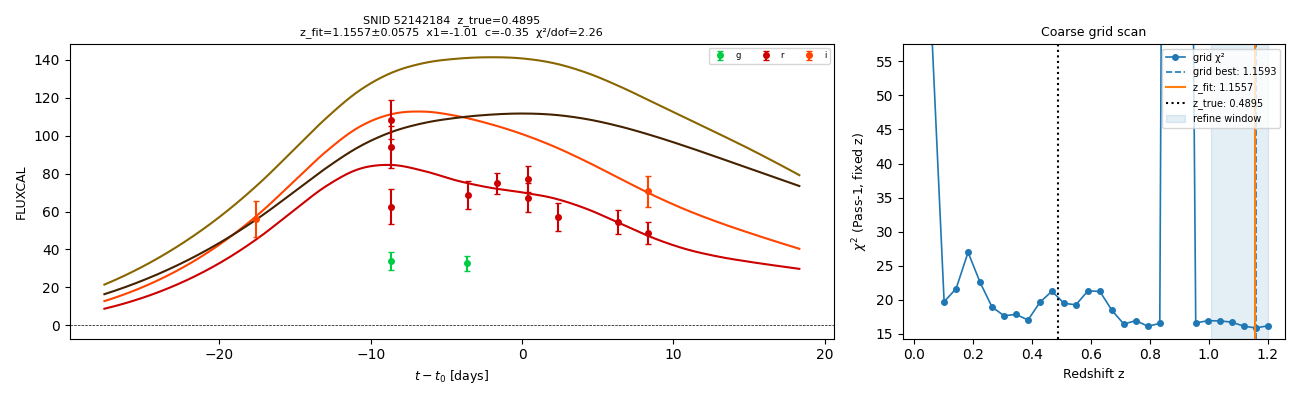

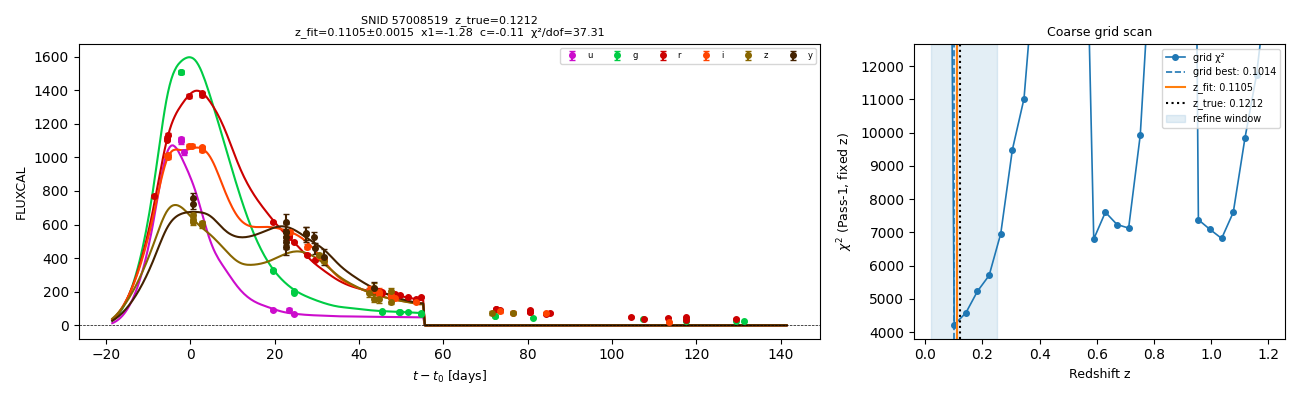

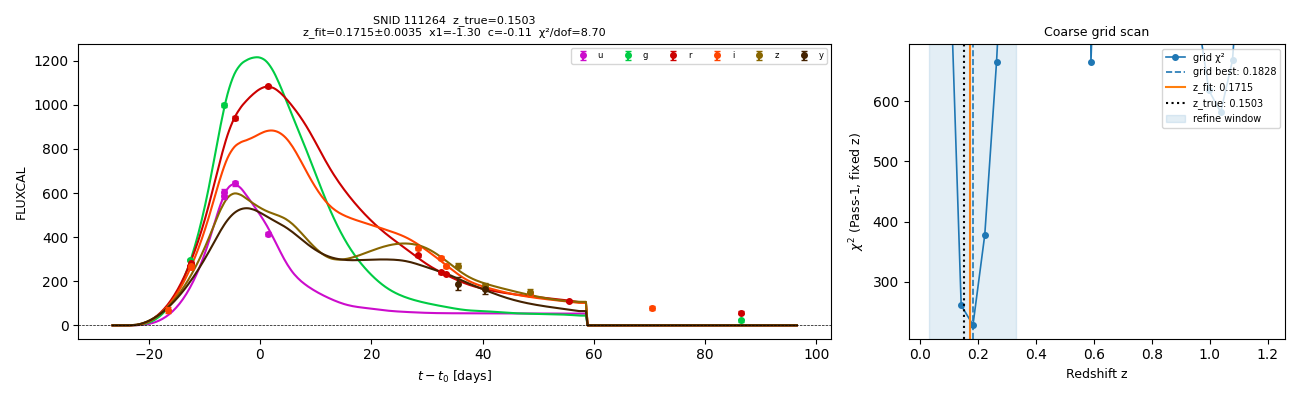

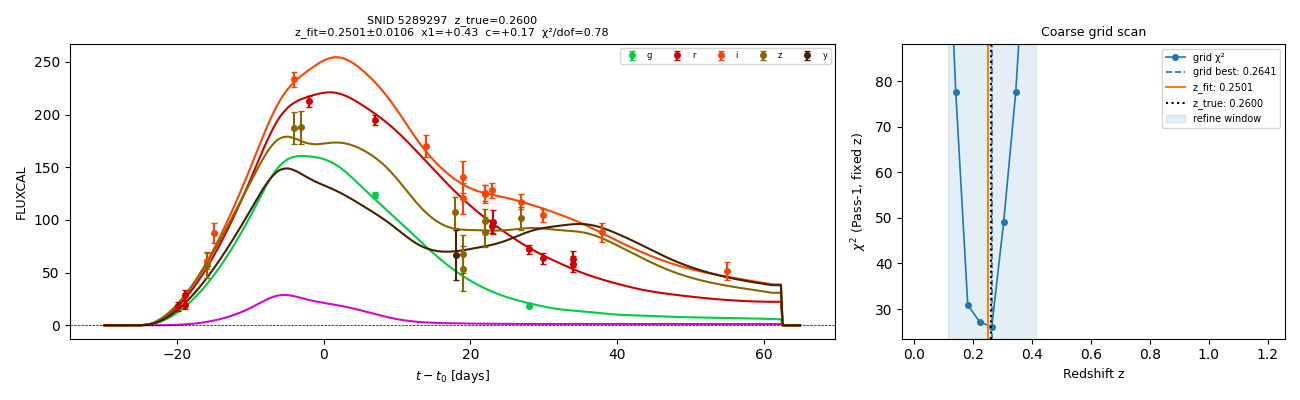

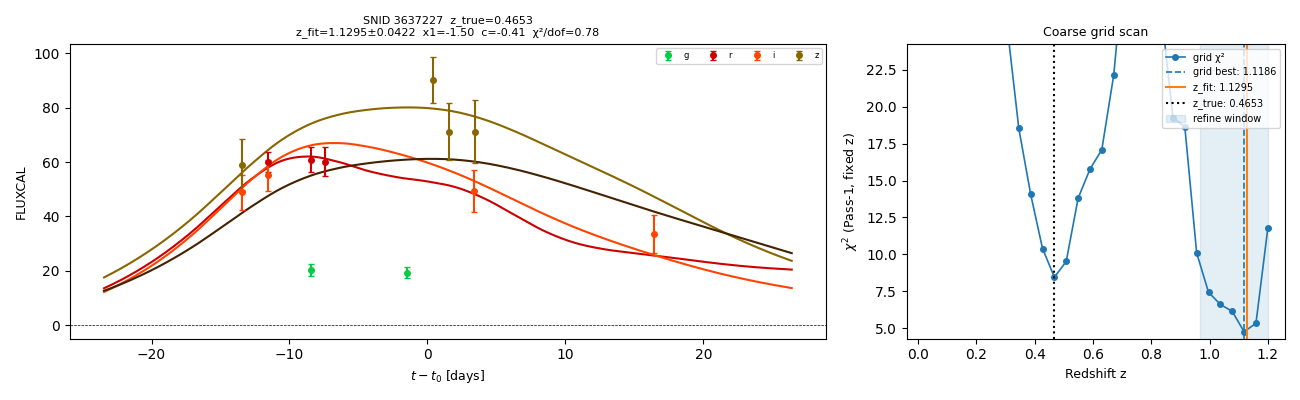

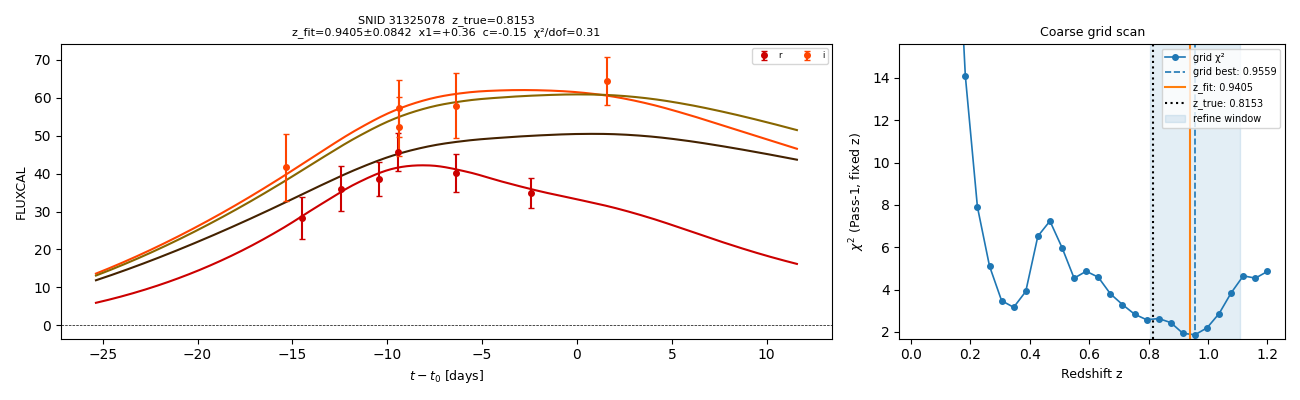

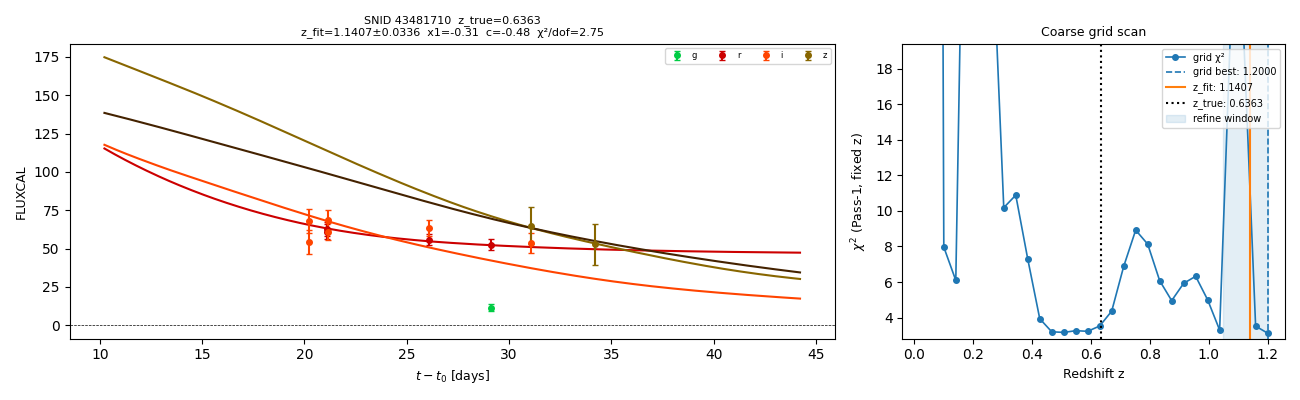

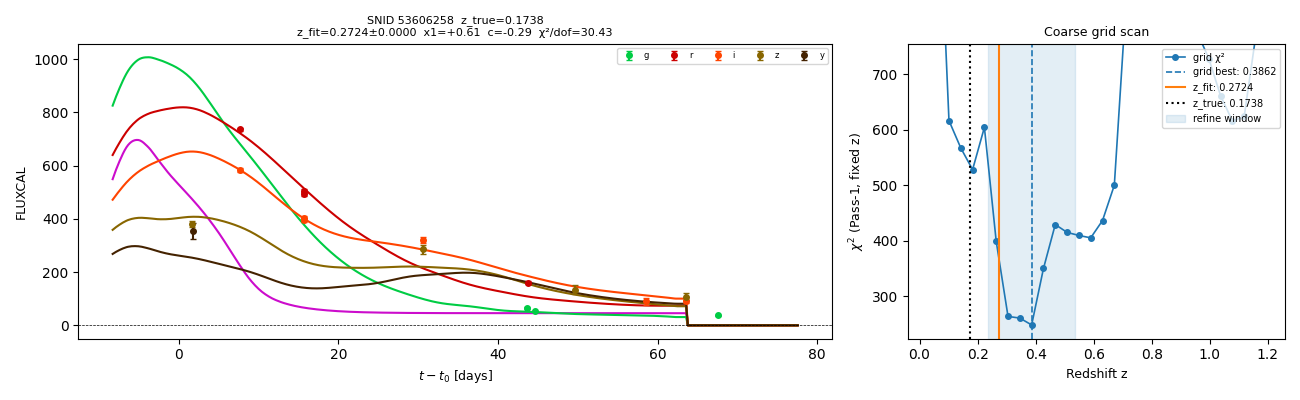

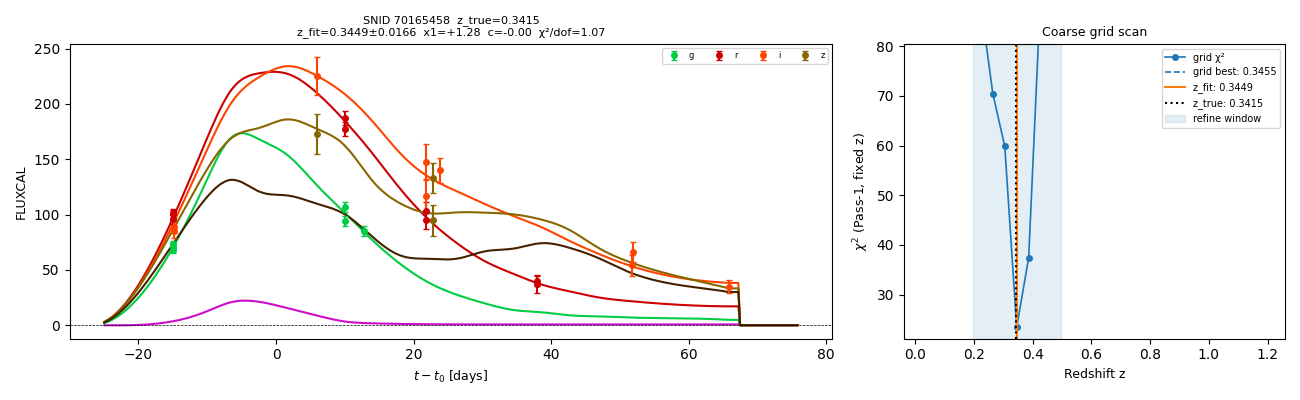

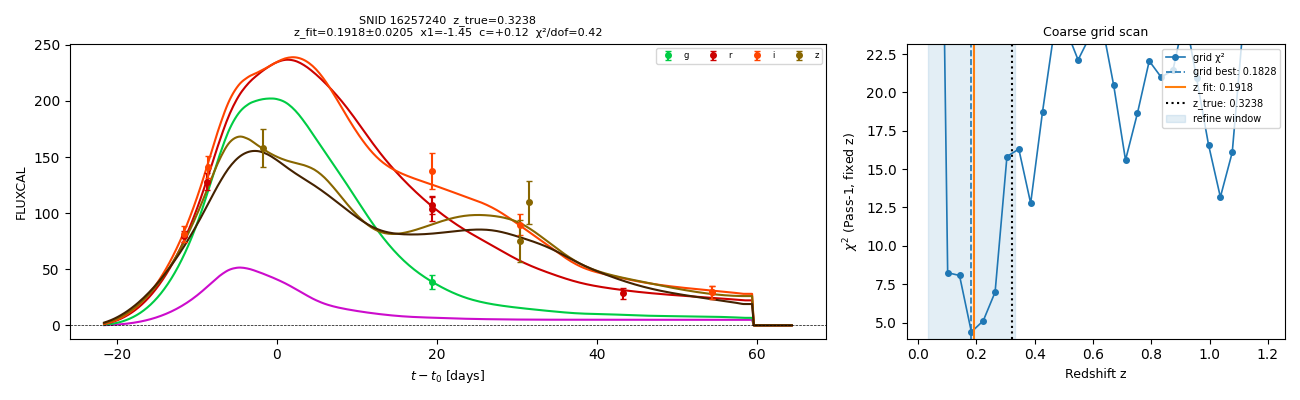

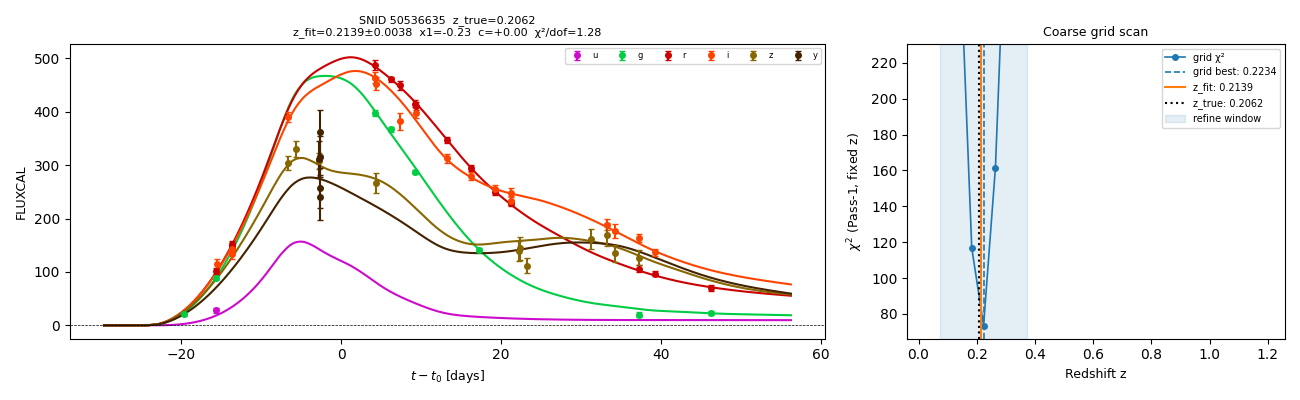

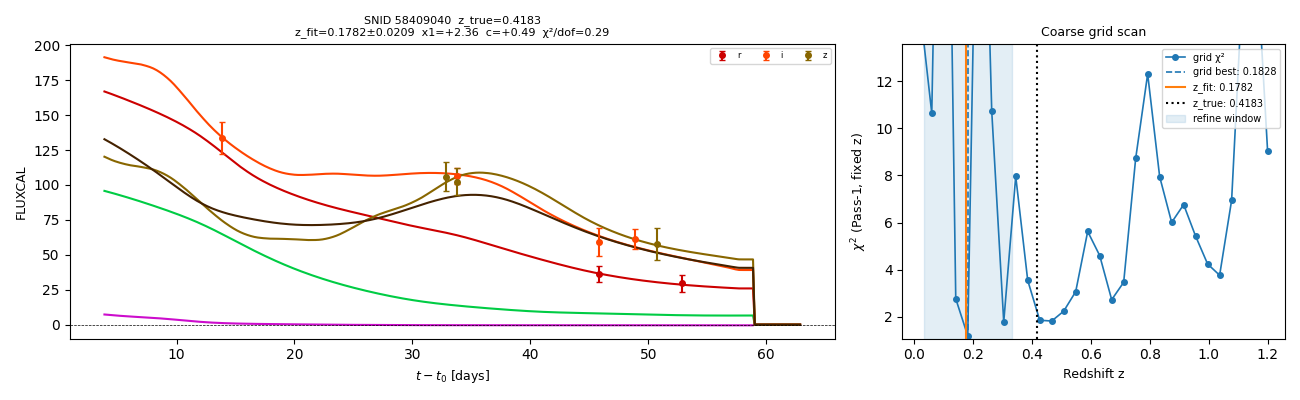

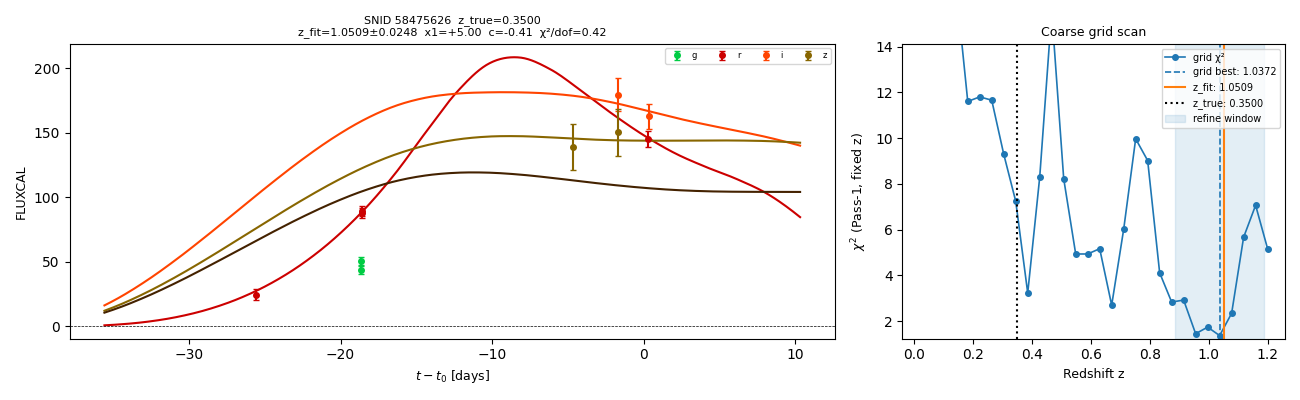

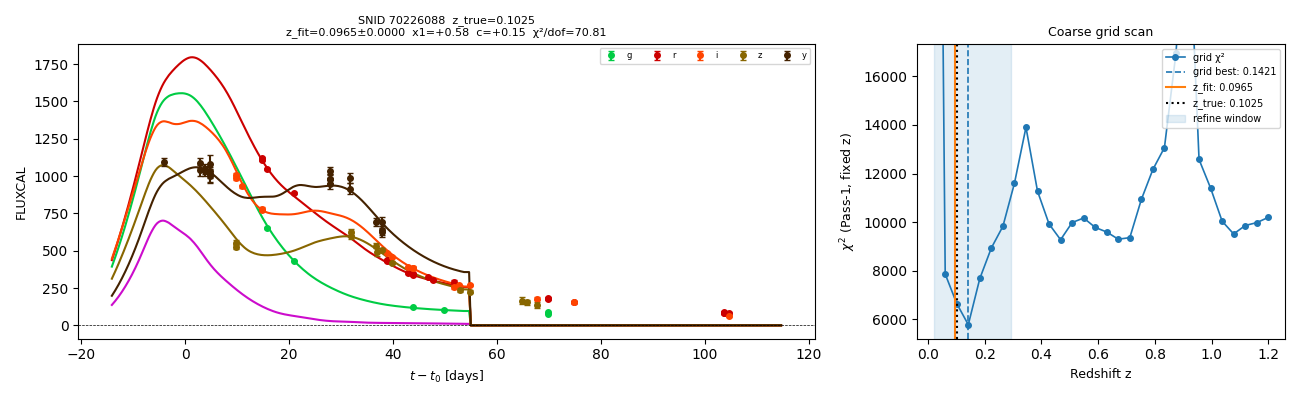

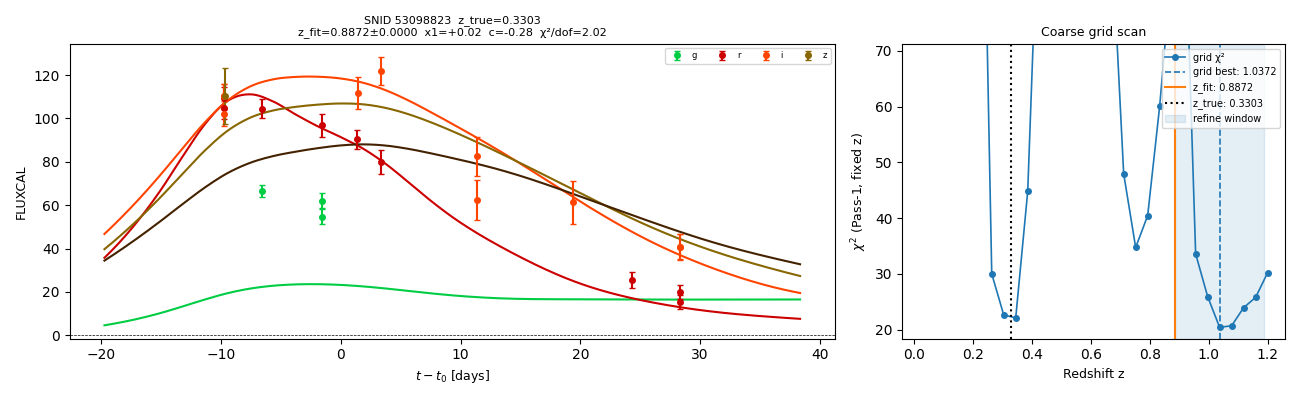

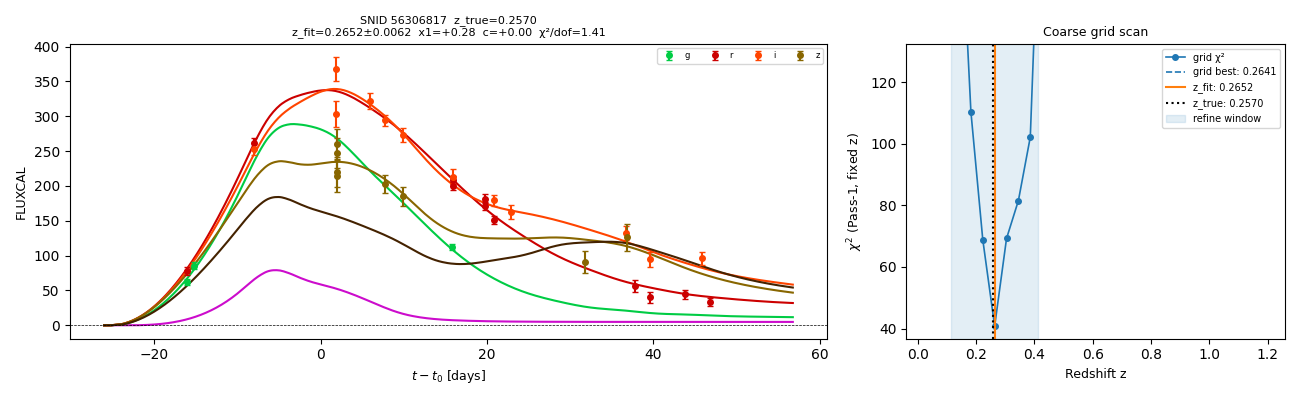

In [11]:
def plot_event_with_zgrid(snid, res, z_true):
    """Two-panel figure: light curve (left) + χ²(z) grid scan (right)."""
    fig, (ax_lc, ax_z) = plt.subplots(1, 2, figsize=(13, 4),
                                       gridspec_kw={'width_ratios': [2, 1]},
                                       tight_layout=True)

    # ── Left panel: light curve ────────────────────────────────────────────────
    if res.get('success'):
        obs          = res['table']
        fitted_model = res['fitted_model']
        t0           = res['t0']
        pe           = res['param_errors']
        t_dense = np.linspace(float(obs['time'].min()) - 10,
                               float(obs['time'].max()) + 10, 400)
        for b in BANDS:
            bname = BAND_PREFIX + b
            color = BAND_COLORS[b]
            mask  = np.array(obs['band']) == bname
            if mask.sum() > 0:
                ax_lc.errorbar(
                    obs['time'][mask] - t0, obs['flux'][mask],
                    yerr=obs['fluxerr'][mask],
                    color=color, ls='None', marker='o',
                    ms=4, capsize=2, label=b, zorder=3
                )
            try:
                f_model = fitted_model.bandflux(bname, t_dense, zp=ZP, zpsys=ZPSYS)
                valid   = np.isfinite(f_model)
                if valid.sum() > 1:
                    ax_lc.plot(t_dense[valid] - t0, f_model[valid],
                               color=color, lw=1.5, zorder=2)
            except Exception:
                pass
        ax_lc.axhline(0.0, color='k', lw=0.5, ls='--')
        ax_lc.set_title(
            f"SNID {snid}  z_true={z_true:.4f}\n"
            f"z_fit={res['z']:.4f}±{pe.get('z',float('nan')):.4f}  "
            f"x1={res['x1']:+.2f}  c={res['c']:+.2f}  "
            f"χ²/dof={res['chi2_red']:.2f}",
            fontsize=8
        )
        ax_lc.legend(fontsize=6, ncol=6, loc='upper right')
    else:
        ax_lc.set_title(f"SNID {snid}\nFit failed", color='red', fontsize=9)

    ax_lc.set_xlabel(r'$t - t_0$ [days]', fontsize=9)
    ax_lc.set_ylabel('FLUXCAL', fontsize=9)

    # ── Right panel: χ²(z) grid scan ─────────────────────────────────────────
    z_grid    = res.get('z_grid')
    chi2_grid = res.get('chi2_grid')
    if z_grid is not None and chi2_grid is not None:
        # Clip to finite values for display
        finite = np.isfinite(chi2_grid)
        ax_z.plot(z_grid[finite], chi2_grid[finite],
                  'C0o-', ms=4, lw=1.2, label='grid χ²')

        z_best_grid = res.get('z_grid_best', float('nan'))
        chi2_best_grid = chi2_grid[np.argmin(chi2_grid)] if finite.any() else float('nan')
        ax_z.axvline(z_best_grid, color='C0', ls='--', lw=1.2,
                     label=f'grid best: {z_best_grid:.4f}')

        if res.get('success'):
            ax_z.axvline(res['z'], color='C1', ls='-', lw=1.5,
                         label=f'z_fit: {res["z"]:.4f}')

        ax_z.axvline(z_true, color='k', ls=':', lw=1.5,
                     label=f'z_true: {z_true:.4f}')

        # Shade refine window
        lo = max(Z_BOUND_LO, z_best_grid - Z_REFINE_HALF)
        hi = min(Z_BOUND_HI, z_best_grid + Z_REFINE_HALF)
        ax_z.axvspan(lo, hi, alpha=0.12, color='C0',
                     label='refine window')

        # Zoom y-axis to a reasonable range
        chi2_min = chi2_grid[finite].min() if finite.any() else 0
        ax_z.set_ylim(chi2_min * 0.9,
                      min(chi2_grid[finite].max(), chi2_min * 3 + 10) if finite.any() else 100)
        ax_z.legend(fontsize=7, loc='upper right')

    ax_z.set_xlabel('Redshift z', fontsize=9)
    ax_z.set_ylabel(r'$\chi^2$ (Pass-1, fixed z)', fontsize=9)
    ax_z.set_title('Coarse grid scan', fontsize=9)

    return fig


# ── Draw grid of per-event figures ─────────────────────────────────────────────
# Limit display to first N_PLOT events to avoid an enormous output
N_PLOT = min(n_avail, 20)

for snid in chosen_snids[:N_PLOT]:
    z_row  = truth[truth['SNID'] == snid]['ZCMB'].values
    z_true = float(z_row[0]) if len(z_row) else np.nan
    fig = plot_event_with_zgrid(snid, fit_results[snid], z_true)
    plt.show()

## 7 · Summary table

In [12]:
rows = []
for snid in chosen_snids:
    res    = fit_results[snid]
    z_row  = truth[truth['SNID'] == snid]['ZCMB'].values
    z_true = float(z_row[0]) if len(z_row) else np.nan
    pe     = res.get('param_errors', {})

    row = {'SNID': snid, 'z_true': round(z_true, 4),
           'success': res.get('success', False)}
    if res.get('success'):
        dz = res['z'] - z_true
        row.update({
            'z_fit'    : round(res['z'],       4),
            'z_err'    : round(pe.get('z', float('nan')), 4),
            'dz'       : round(dz, 4),
            'dz_1pz'   : round(dz / (1.0 + z_true), 4),
            'x1'       : round(res['x1'], 3),
            'x1_err'   : round(pe.get('x1', float('nan')), 3),
            'c'        : round(res['c'],  3),
            'c_err'    : round(pe.get('c', float('nan')), 3),
            'chi2'     : round(res['chi2'],    2),
            'ndof'     : res['ndof'],
            'chi2_red' : round(res['chi2_red'], 3),
        })
    rows.append(row)

df_results = pd.DataFrame(rows)
df_ok = df_results[df_results['success']].copy()

print(f"Fit summary  : {len(df_ok)} / {n_avail} converged")
print(f"Median Δz    : {df_ok['dz'].median():+.4f}")
print(f"RMS Δz       : {df_ok['dz'].std():.4f}")
print(f"Median Δz/(1+z) : {df_ok['dz_1pz'].median():+.5f}")
print(f"RMS  Δz/(1+z)   : {df_ok['dz_1pz'].std():.5f}")
print()
print(df_ok[['SNID','z_true','z_fit','z_err','dz','dz_1pz','chi2_red']].to_string(index=False))

Fit summary  : 200 / 200 converged
Median Δz    : +0.0207
RMS Δz       : 0.2962
Median Δz/(1+z) : +0.01715
RMS  Δz/(1+z)   : 0.20997

    SNID  z_true  z_fit  z_err      dz  dz_1pz  chi2_red
42107438  0.5128 1.0445 0.0230  0.5317  0.3515     1.272
29989905  0.3983 0.8872 0.0005  0.4889  0.3497     1.607
24244586  0.5183 0.6956 0.0483  0.1773  0.1168     0.619
 6201746  0.1075 1.1212 0.1354  1.0137  0.9153     0.403
52142184  0.4895 1.1557 0.0575  0.6662  0.4473     2.265
57008519  0.1212 0.1105 0.0015 -0.0107 -0.0095    37.310
  111264  0.1503 0.1715 0.0035  0.0212  0.0184     8.705
 5289297  0.2600 0.2501 0.0106 -0.0098 -0.0078     0.781
 3637227  0.4653 1.1295 0.0422  0.6642  0.4533     0.781
31325078  0.8153 0.9405 0.0842  0.1252  0.0689     0.306
43481710  0.6363 1.1407 0.0336  0.5044  0.3083     2.749
53606258  0.1738 0.2724 0.0000  0.0986  0.0840    30.430
70165458  0.3415 0.3449 0.0166  0.0034  0.0025     1.068
16257240  0.3238 0.1918 0.0205 -0.1320 -0.0997     0.419
50536635  0

## 8 · Distribution of SALT3 parameters

/var/folders/79/hrybm_4s0zjd4jsb7lp_trhh0000gp/T/ipykernel_80302/1106300287.py:9: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig2, axes2 = plt.subplots(1, len(params),


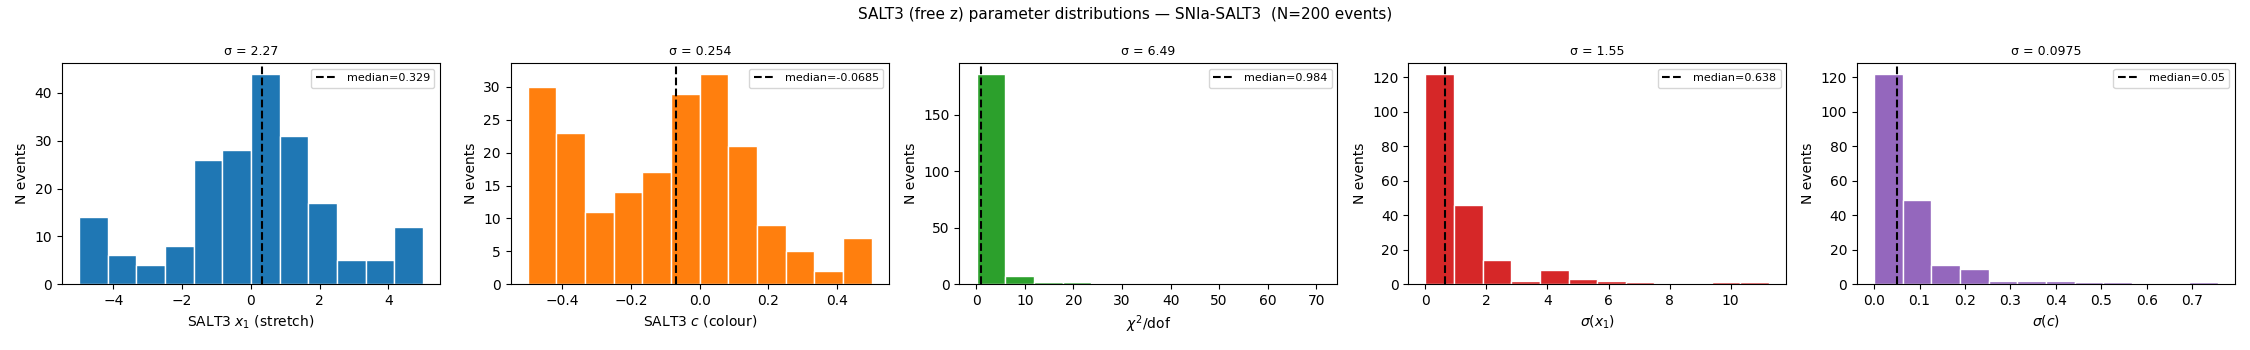

In [13]:
params = ['x1', 'c', 'chi2_red', 'x1_err', 'c_err']
labels = {
    'x1'      : r'SALT3 $x_1$ (stretch)',
    'c'       : r'SALT3 $c$ (colour)',
    'chi2_red': r'$\chi^2$/dof',
    'x1_err'  : r'$\sigma(x_1)$',
    'c_err'   : r'$\sigma(c)$',
}
fig2, axes2 = plt.subplots(1, len(params),
                            figsize=(4.5 * len(params), 3.5),
                            tight_layout=True)
for ax, par, col in zip(axes2, params, ['C0','C1','C2','C3','C4']):
    vals = df_ok[par].dropna()
    if len(vals) == 0:
        continue
    ax.hist(vals, bins=12, color=col, edgecolor='white')
    ax.axvline(np.median(vals), color='k', ls='--', lw=1.5,
               label=f'median={np.median(vals):.3g}')
    ax.set_xlabel(labels[par], fontsize=10)
    ax.set_ylabel('N events', fontsize=10)
    ax.set_title(f'σ = {np.std(vals):.3g}', fontsize=9)
    ax.legend(fontsize=8)
fig2.suptitle(
    f"SALT3 (free z) parameter distributions — {OBJ_CLASS}  "
    f"(N={len(df_ok)} events)",
    fontsize=11
)
plt.show()

## 9 · Photometric redshift performance: `z_fit` vs `z_true`

This is the key diagnostic of free-z SALT3 fitting.

Three panels:
1. **Main**: errorbar plot `z_fit ± σ_z` vs `z_true`, colour-coded by χ²/dof.
   The dashed diagonal is the ideal $z_{\rm fit} = z_{\rm true}$ line.
2. **Residual**: $\Delta z = z_{\rm fit} - z_{\rm true}$ vs `z_true` with
   horizontal reference at 0.
3. **Normalised residual**: $\Delta z / (1 + z_{\rm true})$ vs `z_true`
   (equivalent to a peculiar velocity offset in units of $c$, and the standard
   figure-of-merit for photometric redshift quality).

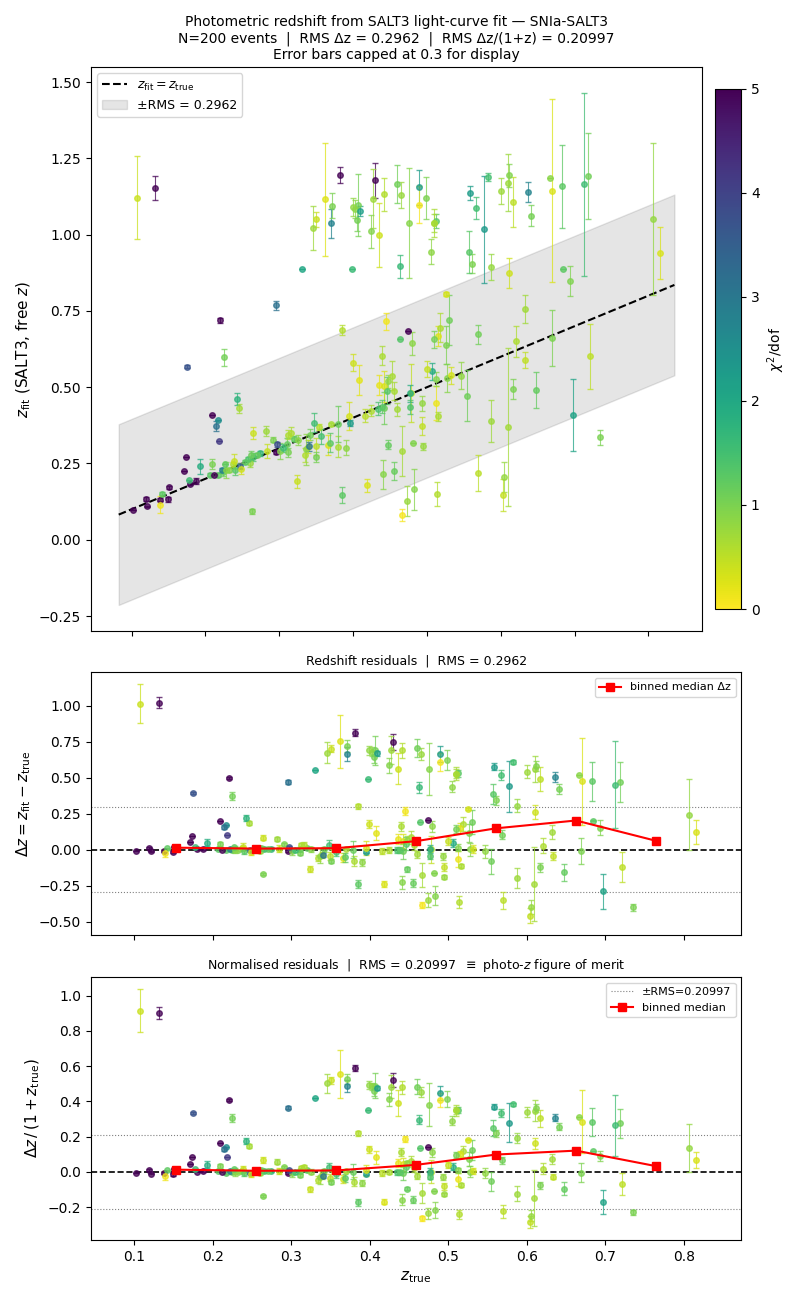

In [14]:
# ── Collect arrays ─────────────────────────────────────────────────────────────
z_true_arr  = df_ok['z_true'].values
z_fit_arr   = df_ok['z_fit'].values
z_err_arr   = df_ok['z_err'].values
chi2_arr    = df_ok['chi2_red'].values
dz_arr      = df_ok['dz'].values
dz_1pz_arr  = df_ok['dz_1pz'].values

# Clamp z_err for display (very large errors distort the figure)
Z_ERR_MAX = 0.3
z_err_display = np.clip(z_err_arr, 0, Z_ERR_MAX)

# ── Build figure ───────────────────────────────────────────────────────────────
fig9, axes9 = plt.subplots(
    3, 1, figsize=(8, 13),
    sharex=True,
    gridspec_kw={'height_ratios': [3, 1.4, 1.4]},
    tight_layout=True
)

# Shared colourmap by χ²/dof
cmap   = plt.cm.viridis_r
norm   = matplotlib.colors.Normalize(vmin=0, vmax=5)
colors = cmap(norm(np.clip(chi2_arr, 0, 5)))

# ── Panel 1: z_fit ± σ_z  vs  z_true ──────────────────────────────────────────
ax1 = axes9[0]
for i in range(len(z_true_arr)):
    ax1.errorbar(
        z_true_arr[i], z_fit_arr[i],
        yerr=z_err_display[i],
        fmt='o', ms=4,
        color=colors[i],
        ecolor=colors[i],
        alpha=0.75, capsize=2, lw=0.8,
        zorder=3
    )

# Reference diagonal z_fit = z_true
z_ref = np.linspace(max(Z_BOUND_LO, z_true_arr.min() - 0.02),
                    min(Z_BOUND_HI, z_true_arr.max() + 0.02), 200)
ax1.plot(z_ref, z_ref, 'k--', lw=1.5, label=r'$z_{\rm fit} = z_{\rm true}$', zorder=2)

# Optional: ±σ band around the diagonal
rms_dz = float(df_ok['dz'].std())
ax1.fill_between(z_ref, z_ref - rms_dz, z_ref + rms_dz,
                 alpha=0.10, color='k',
                 label=f'±RMS = {rms_dz:.4f}')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cb = fig9.colorbar(sm, ax=ax1, pad=0.02, fraction=0.04)
cb.set_label(r'$\chi^2$/dof', fontsize=10)

ax1.set_ylabel(r'$z_{\rm fit}$ (SALT3, free $z$)', fontsize=11)
ax1.set_title(
    f"Photometric redshift from SALT3 light-curve fit — {OBJ_CLASS}\n"
    f"N={len(df_ok)} events  |  "
    f"RMS Δz = {rms_dz:.4f}  |  "
    f"RMS Δz/(1+z) = {float(df_ok['dz_1pz'].std()):.5f}\n"
    f"Error bars capped at {Z_ERR_MAX} for display",
    fontsize=10
)
ax1.legend(fontsize=9, loc='upper left')

# ── Panel 2: Δz = z_fit − z_true ──────────────────────────────────────────────
ax2 = axes9[1]
for i in range(len(z_true_arr)):
    ax2.errorbar(
        z_true_arr[i], dz_arr[i],
        yerr=z_err_display[i],
        fmt='o', ms=4,
        color=colors[i], ecolor=colors[i],
        alpha=0.75, capsize=2, lw=0.8, zorder=3
    )
ax2.axhline(0.0, color='k', lw=1.2, ls='--')
ax2.axhline(+rms_dz, color='gray', lw=0.8, ls=':')
ax2.axhline(-rms_dz, color='gray', lw=0.8, ls=':')

# Running median in z bins
try:
    z_bins = np.linspace(z_true_arr.min(), z_true_arr.max(), 8)
    z_bin_cen = 0.5 * (z_bins[:-1] + z_bins[1:])
    dz_median = [
        np.median(dz_arr[(z_true_arr >= z_bins[k]) & (z_true_arr < z_bins[k+1])])
        for k in range(len(z_bin_cen))
    ]
    ax2.plot(z_bin_cen, dz_median, 'rs-', ms=6, lw=1.5,
             label='binned median Δz', zorder=5)
    ax2.legend(fontsize=8)
except Exception:
    pass

ax2.set_ylabel(r'$\Delta z = z_{\rm fit} - z_{\rm true}$', fontsize=11)
ax2.set_title(f'Redshift residuals  |  RMS = {rms_dz:.4f}', fontsize=9)

# ── Panel 3: Δz / (1+z_true) ──────────────────────────────────────────────────
ax3 = axes9[2]
rms_dz1pz = float(df_ok['dz_1pz'].std())
for i in range(len(z_true_arr)):
    ax3.errorbar(
        z_true_arr[i], dz_1pz_arr[i],
        yerr=z_err_display[i] / (1.0 + z_true_arr[i]),
        fmt='o', ms=4,
        color=colors[i], ecolor=colors[i],
        alpha=0.75, capsize=2, lw=0.8, zorder=3
    )
ax3.axhline(0.0, color='k', lw=1.2, ls='--')
ax3.axhline(+rms_dz1pz, color='gray', lw=0.8, ls=':', label=f'±RMS={rms_dz1pz:.5f}')
ax3.axhline(-rms_dz1pz, color='gray', lw=0.8, ls=':')

# Running median
try:
    dz1pz_median = [
        np.median(dz_1pz_arr[(z_true_arr >= z_bins[k]) & (z_true_arr < z_bins[k+1])])
        for k in range(len(z_bin_cen))
    ]
    ax3.plot(z_bin_cen, dz1pz_median, 'rs-', ms=6, lw=1.5,
             label='binned median', zorder=5)
    ax3.legend(fontsize=8)
except Exception:
    pass

ax3.set_xlabel(r'$z_{\rm true}$', fontsize=11)
ax3.set_ylabel(r'$\Delta z\,/\,(1+z_{\rm true})$', fontsize=11)
ax3.set_title(
    rf'Normalised residuals  |  RMS = {rms_dz1pz:.5f}  '
    r'$\equiv$ photo-$z$ figure of merit',
    fontsize=9
)

plt.tight_layout()
plt.show()

## 10 · Distribution of redshift residuals

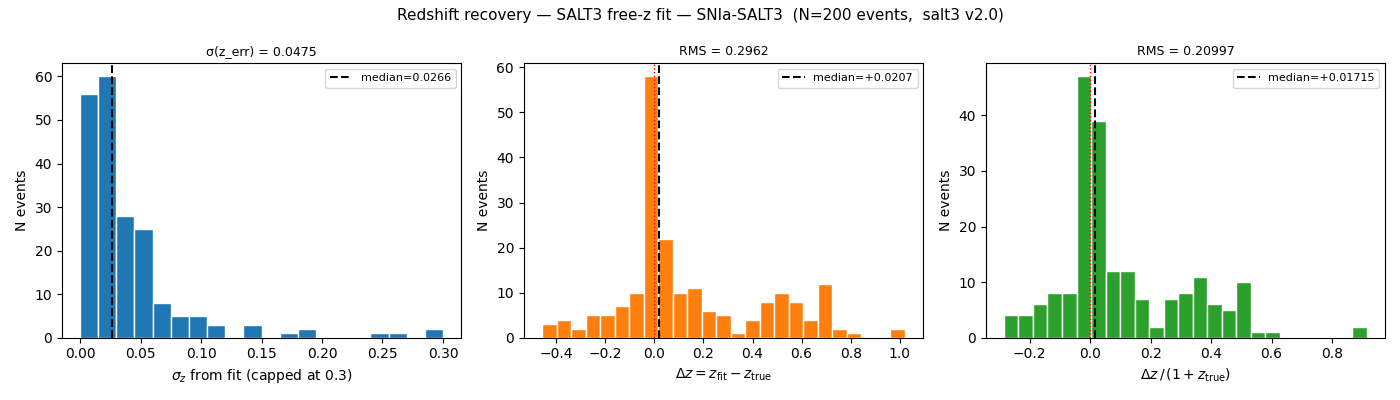

In [15]:
fig10, axes10 = plt.subplots(1, 3, figsize=(14, 4), tight_layout=True)

# Panel A: histogram of z_err
vals_zerr = df_ok['z_err'].clip(upper=Z_ERR_MAX)
axes10[0].hist(vals_zerr, bins=20, color='C0', edgecolor='white')
axes10[0].axvline(np.median(vals_zerr), color='k', ls='--', lw=1.5,
                  label=f'median={np.median(vals_zerr):.4f}')
axes10[0].set_xlabel(r'$\sigma_z$ from fit (capped at 0.3)', fontsize=10)
axes10[0].set_ylabel('N events', fontsize=10)
axes10[0].set_title(f'σ(z_err) = {vals_zerr.std():.4f}', fontsize=9)
axes10[0].legend(fontsize=8)

# Panel B: histogram of Δz
axes10[1].hist(df_ok['dz'], bins=25, color='C1', edgecolor='white')
axes10[1].axvline(np.median(df_ok['dz']), color='k', ls='--', lw=1.5,
                  label=f'median={np.median(df_ok["dz"]):+.4f}')
axes10[1].axvline(0.0, color='r', ls=':', lw=1.0)
axes10[1].set_xlabel(r'$\Delta z = z_{\rm fit} - z_{\rm true}$', fontsize=10)
axes10[1].set_ylabel('N events', fontsize=10)
axes10[1].set_title(f'RMS = {df_ok["dz"].std():.4f}', fontsize=9)
axes10[1].legend(fontsize=8)

# Panel C: histogram of Δz/(1+z)
axes10[2].hist(df_ok['dz_1pz'], bins=25, color='C2', edgecolor='white')
axes10[2].axvline(np.median(df_ok['dz_1pz']), color='k', ls='--', lw=1.5,
                  label=f'median={np.median(df_ok["dz_1pz"]):+.5f}')
axes10[2].axvline(0.0, color='r', ls=':', lw=1.0)
axes10[2].set_xlabel(r'$\Delta z\,/\,(1+z_{\rm true})$', fontsize=10)
axes10[2].set_ylabel('N events', fontsize=10)
axes10[2].set_title(f'RMS = {df_ok["dz_1pz"].std():.5f}', fontsize=9)
axes10[2].legend(fontsize=8)

fig10.suptitle(
    f"Redshift recovery — SALT3 free-z fit — {OBJ_CLASS}  "
    f"(N={len(df_ok)} events,  {SALT3_SOURCE} v{SALT3_VERSION})",
    fontsize=11
)
plt.show()

## Summary

### Parameter status in this notebook

| Parameter | Notebook 03 | This notebook (03b) |
|-----------|-------------|---------------------|
| `z`  | **fixed** to truth | **free** — fitted from light curves |
| `t0` | free | free |
| `x0` | free | free |
| `x1` | free | free |
| `c`  | free | free |

### Two-pass fitting strategy

| Pass | Parameters | Purpose |
|------|------------|--------|
| 1 — coarse grid scan | `t0, x0, x1, c` (z fixed on grid) | Locate the global χ² minimum in z |
| 2 — refined free fit | `z, t0, x0, x1, c` (all free) | Precise parameters + covariance |

### Key caveats

- Without spectroscopic host redshift, the z–c degeneracy limits precision,
  especially at high redshift where rest-frame UV bands shift out of the LSST
  optical window.
- The fit bounds `[Z_BOUND_LO, Z_BOUND_HI]` play the role of a prior; in a real
  analysis they would be derived from the host galaxy photometric redshift or
  from population priors.
- The σ_z returned by `sncosmo.fit_lc` is the **statistical** uncertainty from the
  covariance matrix. It underestimates the true uncertainty because it does not
  account for model misspecification, intrinsic scatter, or dust.
- Events with χ²/dof >> 1 are likely outliers (failed convergence, wrong local
  minimum, or genuinely anomalous light curves); they should be filtered before
  cosmological analysis.
